In [1]:
import numpy as np

print("NumPy version:", np.__version__)

NumPy version: 2.3.4


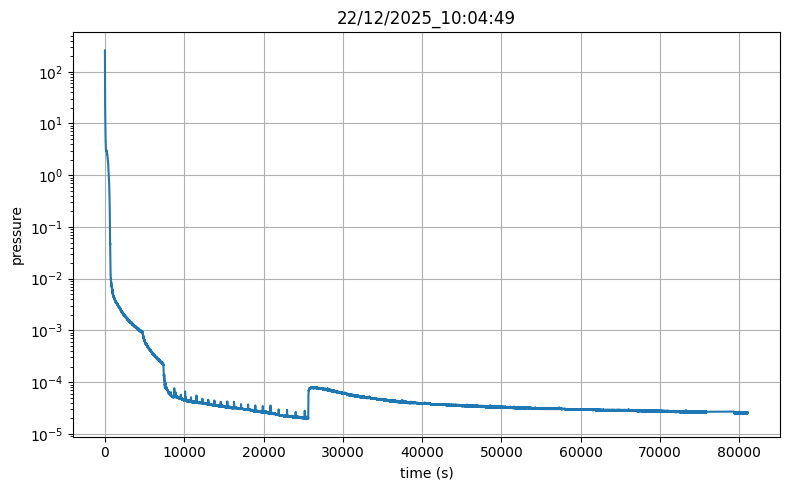

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Path to your .txt file
file_path = '/Volumes/qt/Diamond/Setups/LT5/00_LT5_fiber_array/Cryostat_operation/01_logs/datalog20251222_pump_and_cool_down_from_ambient_conditions.txt'

# --- Step 1: Read the first line separately (the timestamp) ---
with open(file_path, 'r') as f:
    timestamp = f.readline().strip()  # read and remove newline

# --- Step 2: Read the rest of the file as tab-separated data ---
df = pd.read_csv(file_path, sep='\t', skiprows=1)

# --- Step 3: Select the desired columns ---
# Column 1 → X values, Column 13 → Y values (note: 0-based indexing)
x = df.iloc[:, 0]
y = df.iloc[:, 12]

# --- Step 4: Plot ---
plt.figure(figsize=(8, 5))
plt.plot(x, y, linewidth=1.5)
plt.yscale('log')  # set y-axis to logarithmic scale

plt.xlabel("time (s)")
plt.ylabel("pressure")
plt.title(timestamp)  # use the timestamp as the title
plt.grid(True)
plt.tight_layout()
plt.show()


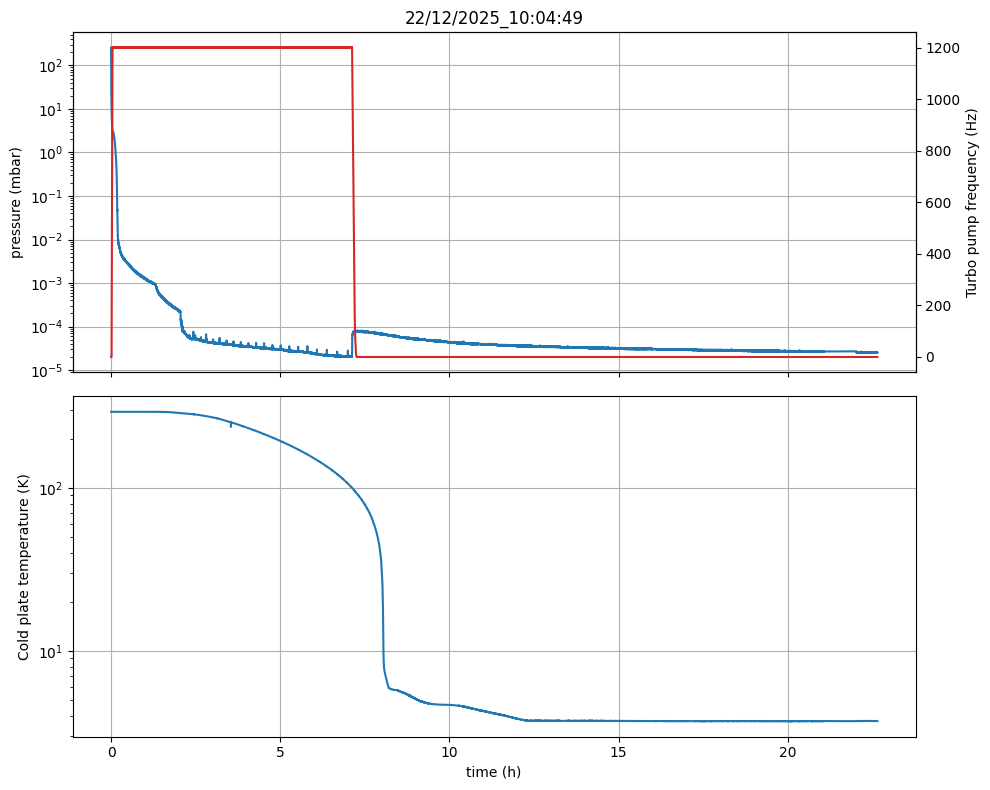

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# File path to your tab-separated .txt file
# file_path = '/Volumes/Diamond/Setups/LT5/00_LT5_fiber_array/Cryostat_operation/datalog20251113_BaseTemperature_pump_and_cool_down_from_ambient_conditions.txt'

# --- Load raw file to extract the timestamp from the first line ---
with open(file_path, "r") as f:
    timestamp_title = f.readline().strip()   # first line is timestamp
    f.readline()  # skip second line (header)

# --- Load numerical data (skip first 2 rows: timestamp + headers) ---
data = np.loadtxt(file_path, delimiter="\t", skiprows=2)

# Extract columns
time = data[:, 0]/3600     # x-axis (seconds)
pressure = data[:, 12]     # column 12
turbo_freq = data[:, 1]    # column 2
cold_plate_temp = data[:, 8]  # column 8

# --- Create figure with two vertical subplots that share x-axis ---
fig, (ax_top, ax_bottom) = plt.subplots(
    2, 1, sharex=True, figsize=(10, 8)
)

# --------------------------------------------------------
# TOP PLOT
# --------------------------------------------------------

# Left y-axis: pressure (log scale)
ax_top.plot(time, pressure, label="Pressure (mbar)")
ax_top.set_yscale("log")
ax_top.set_ylabel("pressure (mbar)")

# Right y-axis: turbo frequency
ax2 = ax_top.twinx()
ax2.plot(time, turbo_freq, color="tab:red", label="Turbo pump frequency (Hz)")
ax2.set_ylabel("Turbo pump frequency (Hz)")

ax_top.grid(True)

# Set timestamp title above the top plot
ax_top.set_title(timestamp_title)

# --------------------------------------------------------
# BOTTOM PLOT
# --------------------------------------------------------

ax_bottom.plot(time, cold_plate_temp, label="Cold plate temp (K)")
ax_bottom.set_yscale("log")
ax_bottom.set_ylabel("Cold plate temperature (K)")
ax_bottom.set_xlabel("time (h)")
ax_bottom.grid(True)

plt.tight_layout()
plt.show()
